In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
"""
1. Injection of global noise via phase shifts and
by frequency offsets.

2. Injection of global and local noise via single
addressing beams causing stark shifts.

"""

import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(1)

In [3]:
date = "2026-02-19"
rid = 94028 #94031# #94028 #94009
sim_outcomes = [0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, ]
m = fh.SO3Model()
num_ions, popt_matrix, perr_matrix = m.pairwise_rb_to_fits(date, rid, sim_outcomes)





In [4]:
plt.figure("Fitted Noise Heatmap")
theta_com_matrix = popt_matrix[:, :, 0] 
theta_diff_matrix = popt_matrix[:, :, 1]
theta_1_matrix = popt_matrix[:, :, 2] 
theta_2_matrix = popt_matrix[:, :, 3]
spam_matrix = popt_matrix[:, :, 4]
def ang_mat2err_mat(theta_matrix):
    err_matrix = np.zeros_like(theta_matrix)
    for i in range(theta_matrix.shape[0]):
        for j in range(theta_matrix.shape[1]):
            err_matrix[i, j] = fh.theta_to_error(theta_matrix[i, j], 0.1)[0]
    return err_matrix

com_matrix = ang_mat2err_mat(theta_com_matrix)
diff_matrix = ang_mat2err_mat(theta_diff_matrix)

def vmin_vmax(matrix):
    nonzero_values = matrix[matrix > 0]
    if len(nonzero_values) == 0:
        return 0.0, 1.0
    vmin = np.min(nonzero_values)
    vmax = np.max(nonzero_values)
    return vmin, vmax
fig_width = gs.get_fig_width()*246/510
fig_height = 1.5*fig_width
fig, axes = plt.subplots(2, 1, figsize=(fig_width, fig_height))


plt.rcParams["axes.grid"] = False

l, u = vmin_vmax(com_matrix)
# alpha map for lower right corner to be transparent
a_map = np.ones_like(com_matrix)
# for i in range(a_map.shape[0]):
#     for j in range(a_map.shape[1]):
#         if i <= j:
#             a_map[i, j] = 0.0

cmap = "inferno"
im0 = axes[0].imshow(com_matrix, cmap=cmap, vmin=l, vmax=u,  origin='lower', alpha=a_map)
axes[0].grid(False)
#axes[0].set_title("", fontsize=12)

cbar0 = plt.colorbar(im0, location="right", ax=axes[0])
cbar0.set_label("Common error per Clifford", fontsize=12)
cbar0.formatter.set_powerlimits((0, 0))

l, u = vmin_vmax(diff_matrix)
cmap = "PuBu"
im1 = axes[1].imshow(diff_matrix, cmap=cmap, vmin=l, vmax=u, origin='lower', alpha=a_map.T)
axes[1].grid(False)
#axes[1].set_title("", fontsize=12)

for i in [0,1]:
    axes[i].set_xlabel("Ion index, $i$")
    axes[i].set_ylabel("Ion index, $j$")
    axes[i].set_xticks(range(num_ions))
    axes[i].set_yticks(range(num_ions))
    axes[i].set_xticklabels(range(1, num_ions+1))
    axes[i].set_yticklabels(range(1, num_ions+1))

# plot cbar with labels in scientific notation
cbar1 = plt.colorbar(im1, location="right", ax=axes[1])
cbar1.set_label("Differential error per Clifford", fontsize=12)
cbar1.formatter.set_powerlimits((0, 0))

# save the figure
f_path = "..\\pdf_figure\\f4_pair.pdf"
fig.savefig(f_path)
plt.rcParams["axes.grid"] = True




IndexError: index 4 is out of bounds for axis 2 with size 4

<Figure size 705.687x436.139 with 0 Axes>

Sqrt Gaussian Fit Parameters:
a: 0.2432 ± 0.0010
b: 0.3667 ± 0.1914
c: 27.0511 ± 0.4945
Sqrt Gaussian Fit Parameters:
a: 0.0532 ± 0.0001
b: 1.4301 ± 0.1325
c: 26.3081 ± 0.3213
Sqrt Gaussian Fit Parameters:
a: 0.2000 ± 0.0008
b: 0.8173 ± 0.1883
c: 27.7311 ± 0.5130


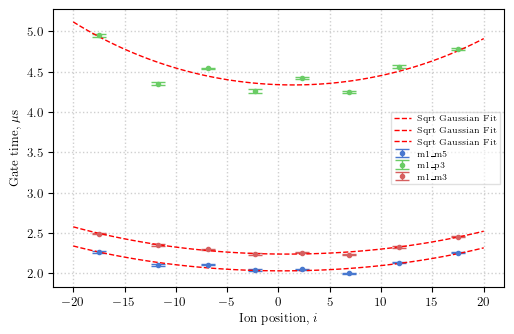

In [ ]:
ion_pos = np.array([-2.4758, -1.6621, -0.96701, -0.31802, 0.31802, 0.96701, 1.6621, 2.4758])*7.0602 # From James 1998, 0.5 MHz trap frequency, 40Ca+ ions, 8 ions
gate_time_m1m5 = [2.26, 2.099, 2.103, 2.040, 2.048, 1.997, 2.128, 2.255]
gate_time_m1m5_err = np.array([10,9,8,9,7,8,8,9])*1e-3
gate_time_m1p3 = [4.95, 4.35, 4.54, 4.26, 4.42, 4.25, 4.56, 4.78]
gate_time_m1p3_err = np.array([2, 2, 1, 2, 1, 1, 2, 1])*1e-2
gate_time_m1m3 = [2.49, 2.349, 2.293, 2.24, 2.252, 2.23, 2.323, 2.454]
gate_time_m1m3_err = np.array([10,9, 10, 10, 8, 10, 8, 9])*1e-3

def sqrt_gaussian(x, a, b, c):
    return 1/np.sqrt(a * np.exp(-((x - b) ** 2) / (2 * c ** 2)))

p0 = [0.5, 0.0, 1.0]
lims = [[0.0, 0.0, 0.0], [100.0, 100, 100.0]]


def fit_and_plot(ion_pos, gate_time, gate_time_err, name):
    popt, pcov = curve_fit(sqrt_gaussian, ion_pos, gate_time, sigma=gate_time_err, absolute_sigma=True, p0=p0, bounds=lims)
    x_sim = np.linspace(-20, 20, 100)
    gate_time_fit = sqrt_gaussian(x_sim, *popt)
    # print fits
    print("Sqrt Gaussian Fit Parameters:")
    print(f"a: {popt[0]:.4f} ± {np.sqrt(pcov[0, 0]):.4f}")
    print(f"b: {popt[1]:.4f} ± {np.sqrt(pcov[1, 1]):.4f}")
    print(f"c: {popt[2]:.4f} ± {np.sqrt(pcov[2, 2]):.4f}")
    plt.errorbar(ion_pos, gate_time, yerr=gate_time_err, fmt='o', capsize=5, label=name)
    plt.plot(x_sim, gate_time_fit, label='Sqrt Gaussian Fit', color='red')
    sigma = popt[2]
    simga_err = np.sqrt(pcov[2, 2])
    return sigma, simga_err

plt.figure("Gate Time vs Ion Position")
plt.xlabel("Ion position, $i$")
plt.ylabel("Gate time, $\\mu$s")
s1 = fit_and_plot(ion_pos, gate_time_m1m5, gate_time_m1m5_err, "m1_m5")
s2 = fit_and_plot(ion_pos, gate_time_m1p3, gate_time_m1p3_err, "m1_p3")
s3 = fit_and_plot(ion_pos, gate_time_m1m3, gate_time_m1m3_err, "m1_m3")
plt.legend()

Gaussian Fit Parameters:
a: 0.2000 ± 0.0015
b: 0.8173 ± 0.3452
c: 27.7311 ± 0.9407
Expected offset: 0.1031 (+-0.0063/--0.0069)


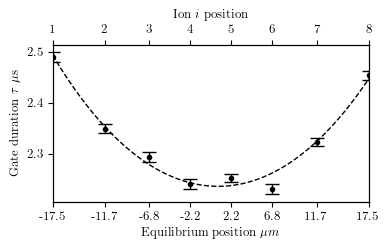

In [ ]:
ts = gate_time_m1m3
ts_err = gate_time_m1m3_err
p0 = [0.2, 1.0, 27.0]
lims = [[0.0, 0.0, 0.0], [100.0, 100.0, 100.0]]
popt, pcov = curve_fit(sqrt_gaussian, ion_pos, ts, sigma=ts_err, p0=p0, bounds=lims)
print("Gaussian Fit Parameters:")
print(f"a: {popt[0]:.4f} ± {np.sqrt(pcov[0, 0]):.4f}")
print(f"b: {popt[1]:.4f} ± {np.sqrt(pcov[1, 1]):.4f}")
print(f"c: {popt[2]:.4f} ± {np.sqrt(pcov[2, 2]):.4f}")
x_sim = np.linspace(min(ion_pos), max(ion_pos), 100)
sim_line = sqrt_gaussian(x_sim, popt[0], popt[1], popt[2])


fig_width = gs.get_fig_width()*0.7
fig_height = gs.get_fig_width()*0.7/2
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.plot(x_sim, sim_line, color='black')

# plot uncertainty band
sim_line_upper = sqrt_gaussian(x_sim, popt[0]+np.sqrt(pcov[0, 0]), popt[1]-0*np.sqrt(pcov[1, 1]), popt[2]+np.sqrt(pcov[2, 2]))
sim_line_lower = sqrt_gaussian(x_sim, popt[0]-np.sqrt(pcov[0, 0]), popt[1]+0*np.sqrt(pcov[1, 1]), popt[2]-np.sqrt(pcov[2, 2]))
# ax.fill_between(x_sim, sim_line_lower, sim_line_upper, color='gray', alpha=0.5, label='Fit Uncertainty')

ax.errorbar(ion_pos, ts, yerr=ts_err, fmt='o', capsize=5, color="black")

exp_offset = 1-min(sim_line)/max(sim_line)
exp_offset_upper = 1-min(sim_line_upper)/max(sim_line_upper)
exp_offset_lower = 1-min(sim_line_lower)/max(sim_line_lower)
print(f"Expected offset: {exp_offset:.4f} (+{exp_offset_upper-exp_offset:.4f}/-{exp_offset-exp_offset_lower:.4f})")

# every second tick label to avoid crowding
ion_pos_2 = ion_pos#[[0,2,-3,-1]]
ax.set_xticks(ion_pos_2)
# round to 2 decimal places
ax.set_xticklabels([f"{pos:.1f}" for pos in ion_pos_2])
ax.set_xlabel("Equilibrium position $\\mu m$")
ax.set_xlim(ion_pos[0], ion_pos[-1])
ax.set_ylabel("Gate duration $\\tau~\\mu$s")

# add another axis on top for the ion index
ax_top = ax.twiny()
ax_top.set_xticks(ion_pos)
ax_top.set_xticklabels(np.array(range(1, 9)))
ax_top.set_xlabel("Ion $i$ position")

ax_top.set_xlim(ion_pos[0], ion_pos[-1])
ax.grid(False)
ax_top.grid(False)


f_path = "..\\..\\pdf_figure\\ch4\\8_ion_gate_time.pdf"
fig.savefig(f_path)



<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'


0.012613924061801044


C:\Users\webbd\AppData\Local\Temp\ipykernel_25224\2207171403.py:37: SyntaxWarning: invalid escape sequence '\m'
  corr_excess_lbl = "$\\varepsilon_\mathrm{corr}^>$"
C:\Users\webbd\AppData\Local\Temp\ipykernel_25224\2207171403.py:115: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(2, num_ions+1, 2))
C:\Users\webbd\AppData\Local\Temp\ipykernel_25224\2207171403.py:125: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(2, num_ions+1, 2))
C:\Users\webbd\AppData\Local\Temp\ipykernel_25224\2207171403.py:115: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(2, num_ions+1, 2))
C:\Users\webbd\AppData\Local\Temp\ipykernel_25224\2207171403.py:115: UserWarning: set_ticklabels() should 

<Figure size 582.677x360.114 with 0 Axes>

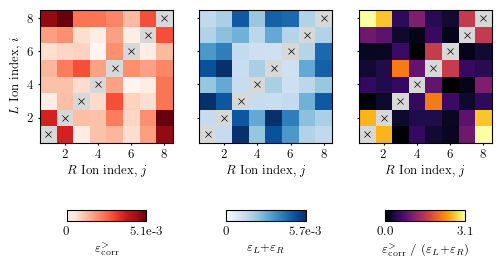

In [47]:
plt.figure("Fitted Noise Heatmap")
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker

fig_width = gs.get_fig_width()
fig_height = fig_width/1
aspect = 7

fig = plt.figure(figsize=(fig_width, fig_height))
grids = GridSpec(1, 3, figure=fig)#, height_ratios=[1, 4, 4, 4, 4, 4], wspace=0.15, hspace=0.30)
# axa = fig.add_subplot(grids[1, :])
# #axb = fig.add_subplot(grids[2, :], sharex=axa)
# #axc = fig.add_subplot(grids[3, :], sharex=axa)
# axd = fig.add_subplot(grids[4, :], sharey=axa)
# axe = fig.add_subplot(grids[5, :], sharey=axa)
#ax1 = fig.add_subplot(grids[0, :])

axa = fig.add_subplot(grids[0, 0])
axd = fig.add_subplot(grids[0, 1], sharey=axa)
axe = fig.add_subplot(grids[0, 2], sharey=axa)

err_corr_matrix = popt_matrix[:, :, 0]
err_L_matrix = popt_matrix[:, :, 1]
err_R_matrix = popt_matrix[:, :, 2]
spam_matrix = popt_matrix[:, :, 3]

def vmin_vmax(matrix):
    nonzero_values = matrix[matrix > 0]
    if len(nonzero_values) == 0:
        return 0.0, 1.0
    vmin = np.min(nonzero_values)
    vmax = np.max(nonzero_values)
    return vmin, vmax

plt.rcParams["axes.grid"] = False

corr_excess_lbl = "$\\varepsilon_\mathrm{corr}^>$"

l, u = vmin_vmax(err_corr_matrix)
offset_l = l
print(offset_l)
err_corr_matrix = err_corr_matrix
a_map = np.ones_like(err_corr_matrix)

cmap = "Reds"
im0 = axa.imshow(err_corr_matrix-offset_l, cmap=cmap, vmin=0, vmax=(u-l),  origin='lower', alpha=a_map)
axa.grid(False)

# set tick labels for colorbar
# make color bar smaller in height
cbar0 = plt.colorbar(im0, location="bottom", ax=axa, shrink=0.6, aspect=aspect)
cbar0.set_ticks([0, u-l], labels=[f"{0:.3f}%", f"{u-l:.3f}%"])
cbar0.set_label(corr_excess_lbl)
    # m.p1_name)
cbar0.ax.tick_params(length=0)
cbar0.ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f'{x:.0e}'
        .replace('e-0', 'e-')
        .replace('e+0', 'e+')
    )
)

cbar0.update_ticks()

# for ax, err_mat, label in zip([axb, axc],[err_L_matrix, err_R_matrix], [m.p2_name, m.p3_name]):
#     l, u = vmin_vmax(err_mat)
#     cmap = "PuBu"
#     im1 = ax.imshow(err_mat, cmap=cmap, vmin=l, vmax=u, origin='lower', alpha=a_map.T)
#     ax.grid(False)
#     #axes[1].set_title("", fontsize=12)
#     # plot cbar with labels in scientific notation
#     cbar1 = plt.colorbar(im1, location="right", ax=ax)
#     cbar1.set_label(label, fontsize=12)

# Plot ratio
depol_matrix = err_L_matrix + err_R_matrix
# replace zeros with small number to avoid division by zero
depol_matrix[depol_matrix == 0] = 1e-10
err_ratio_matrix = (err_corr_matrix-offset_l)/(depol_matrix)#+ err_corr_matrix-offset_l)
for i in range(np.shape(err_ratio_matrix)[0]):
    for j in range(np.shape(err_ratio_matrix)[1]):
        if i == j:
            err_ratio_matrix[i, j] = np.nan
l, u = vmin_vmax(err_ratio_matrix)
cmap = "inferno"
im1 = axe.imshow(err_ratio_matrix, cmap=cmap, vmin=l, vmax=u, origin='lower', alpha=a_map.T)
axe.grid(False)
cbar1 = plt.colorbar(im1, location="bottom", ax=axe, shrink=0.6, aspect=aspect)
cbar1.set_label(f"{corr_excess_lbl} / ({m.p2_name}+{m.p3_name})")
cbar1.set_ticks([l, u], labels=[f"{l:.1f}", f"{u:.1f}"])
cbar1.ax.tick_params(length=0)

# plot depol matrix
l, u = vmin_vmax(depol_matrix)
im1 = axd.imshow(depol_matrix, cmap="Blues", vmin=l, vmax=u, origin='lower', alpha=a_map.T)
axd.grid(False)
cbar2 = plt.colorbar(im1, location="bottom", ax=axd, shrink=0.6, aspect=aspect)
cbar2.set_label(f"{m.p2_name}+{m.p3_name}")
cbar2.set_ticks([l, u], labels=[f"{l:.3f}", f"{u:.3f}"])
cbar2.ax.tick_params(length=0)

#plot diagonal grey entries to indicate where i=j
diag_matrix = np.zeros_like(err_corr_matrix)
#set other entries to nan
for i in range(np.shape(diag_matrix)[0]):
    for j in range(np.shape(diag_matrix)[1]):
        if i != j:
            diag_matrix[i, j] = np.nan
        else:
            diag_matrix[i, j] = 0.25

for ax in [axa, axd, axe]:
        ax.set_xlabel("$R$ Ion index, $j$")
        ax.set_xticklabels(range(2, num_ions+1, 2))
        ax.set_xticks(range(1, num_ions, 2))
        ax.imshow(diag_matrix, cmap="Greys", vmin=0, vmax=1, origin='lower', alpha=1.0)
        # Optional: draw a cross on the diagonal
        n = err_corr_matrix.shape[0]
        for i in range(n):
            ax.plot(i, i, marker="x", color="k", markersize=5, markeredgewidth=0.5)


        if ax == axa:
            ax.set_yticklabels(range(2, num_ions+1, 2))
            ax.set_yticks(range(1, num_ions, 2))
            ax.set_ylabel("$L$ Ion index, $i$")

"""
ax1.plot(x_sim, sim_line, color='black')

# plot uncertainty band
ax1.fill_between(x_sim, sim_line_lower, sim_line_upper, color='gray', alpha=0.5, label='Fit Uncertainty')

# every second tick label to avoid crowding
ion_pos_2 = ion_pos#[[0,2,-3,-1]]
ax1.set_xticks(ion_pos_2)
# round to 2 decimal places
ax1.set_xticklabels([f"{pos:.1f}" for pos in ion_pos_2])
ax1.set_xlabel("Equilibrium position $\\mu m$")
ax1.set_xlim(ion_pos[0], ion_pos[-1])
ax1.set_ylim(1.9, 2.5)
ax1.set_yticks([1.9, 2.1, 2.3, 2.5])
ax1.set_ylabel("$\\tau~\\mu$s")

# add another axis on top for the ion index
ax_top = ax1.twiny()
ax_top.set_xticks(ion_pos)
ax_top.set_xticklabels(np.array(range(1, 9)))
ax_top.set_xlabel("Ion $i$ position")

ax_top.set_xlim(ion_pos[0], ion_pos[-1])
"""

# remove x labels for all but the last plot
# for ax in [axa, axb, axc, axd]:
#     plt.setp(ax.get_xticklabels(), visible=False)
#     ax.set_xlabel("")

for ax in [axd, axe]:
    plt.setp(ax.get_yticklabels(), visible=False)
    ax.set_ylabel("")
for ax in [axa, axd, axe]:
    ax.tick_params(length=1.5)

for cbar in [cbar0, cbar2]:
    ticks = cbar.get_ticks()

    def sci(x):
        if round(x,4) == 0:
            return "0"
        return f"{x:.1e}".replace("e-0", "e-").replace("e+0", "e+")

    cbar.set_ticks(ticks)
    cbar.set_ticklabels([sci(x) for x in ticks])

#save the figure
f_path = "..\\..\\pdf_figure\\ch4\\pair_depol_corr.pdf"
# fig.savefig(f_path)
plt.show()
plt.rcParams["axes.grid"] = True


